<a href="https://colab.research.google.com/github/fuadfach/geog761lab/blob/main/geog761_lab1_fuad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-ffac001')

In [2]:
# Install the geemap package (only needs to be run once, uncomment below and run it the first time you run this notebook in a session).
#!pip install geemap

In [3]:
import geemap
import os

# **Loading a map and displaying satellite data**

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [4]:
# Specify a different kind of basemap to display data layers over
Map = geemap.Map(center=(-36.8485, 174.7633), zoom=14) #<- note the lat-lon coordinate pair here
Map.add_basemap("OpenTopoMap")
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(3) Correct the display of the Landsat 7 image so that it displays in 'True Colour'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [5]:
# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
Map = geemap.Map(center=(-41.0182, 175.3623), zoom=5)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [6]:
# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<- these are HTML colour codes
}

In [7]:
# Add a variety of different Earth Engine layers to the Map object
Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5) #<- note vis params called from the dictionary we set up before
Map.addLayer(landcover, {}, "Land cover")
Map.addLayer(
    landsat7, {"bands": ["B3", "B2", "B1"], "min": 0, "max": 100}, "Landsat 7" #<- note vis params in a dictionary here inside the add layer call
)
Map.addLayer(states, {}, "US States")

In [8]:
# Dump all of this into the map view and take a look...
# Scroll around (look at both NZ and USA), check and uncheck the layers in the layer menu on the top-right.
Map

Map(center=[-41.0182, 175.3623], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

# Cloud cover
(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.
Provide a notebook example of your code that does so, in addition to your table. (5 pts)


In [9]:
import pandas as pd

# Define small region around Alor Island, Indonesia
point = ee.Geometry.Point([124.518393, -8.217483])
region = point.buffer(5000).bounds()


# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))

# Apply mask
    masked_image = image.updateMask(cloud_mask)

# Report Image Quality Over ROI
# Count valid pixels before and after masking
    total_pixels = image.select('SR_B3').reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region,
        scale=30,
        maxPixels=1e9
        ).get('SR_B3')

    valid_pixels = masked_image.select('SR_B3').reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region,
        scale=30,
        maxPixels=1e9
        ).get('SR_B3')

    # get variable total_num and valid_num
    total_num = ee.Number(total_pixels)
    valid_num = ee.Number(valid_pixels)

    # calculate cloud cover percentages from server
    cloud_coverage_pct = ee.Number(100).subtract(
        valid_num.multiply(100).divide(total_num))

    return image.set('REGIONAL_CLOUD_COVER', cloud_coverage_pct)

years = [2005, 2010, 2015]
data_summary = []

for year in years:
    # Filter collection for the region and calendar year
    image = (ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
           .filterBounds(region) \
           .filterDate(f"{year}-01-01", f"{year}-12-31")
           .map(mask_clouds))

    # Calculate the regional average cloud cover & number of images in a year
    avg_cloud = image.aggregate_mean('REGIONAL_CLOUD_COVER').getInfo()
    img_count = image.size().getInfo()

    data_summary.append({
        'Year': year,
        'Total Images': img_count,
        'Avg Regional Cloud Cover (%)': round(avg_cloud, 2) if avg_cloud is not None else 0.0
    })

# 4. Display results as a Table
df_result = pd.DataFrame(data_summary)
df_result



,Year,Total Images,Avg Regional Cloud Cover (%)
0,2005,41,35.19
1,2010,38,49.81
2,2015,43,36.49


# Final exercise
(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




Total Pixels: 110642
Valid (non-cloud) Pixels: 109323
Estimated Cloud Coverage in ROI: 1.19%


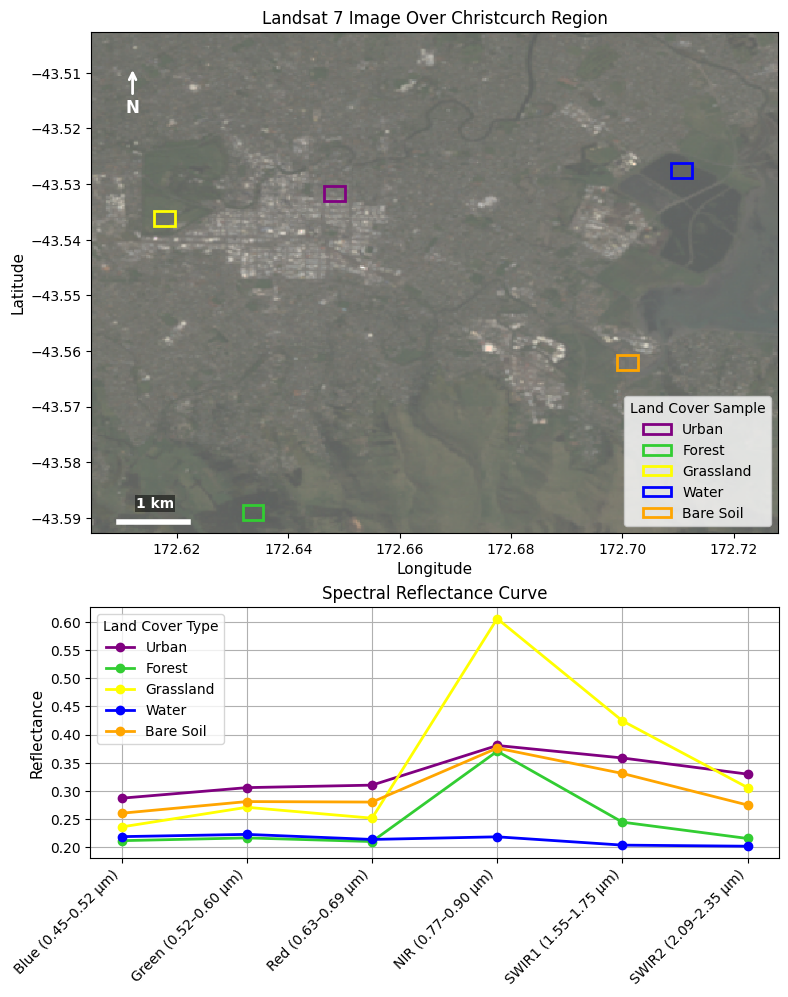

In [14]:
# Additional required packages
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import urllib.request
import tempfile
import matplotlib.image as mpimg

# Define Christcurch point and regions
chc_point = ee.Geometry.Point([172.6662, -43.547679])
chc_expanded_region = chc_point.buffer(5000).bounds()  # box for image preview

# Define sample
samples = {
    'Urban': ee.Geometry.Point([172.648325, -43.531728]),   # CBD Christchurch
    'Forest': ee.Geometry.Point([172.633624, -43.589]),  # Christchurch Adventure Park
    'Grassland': ee.Geometry.Point([172.6178, -43.536248]), # Hagley Park Grass
    'Water': ee.Geometry.Point([172.710679, -43.527550]),   # Bromley pond
    'Bare Soil': ee.Geometry.Point([172.701, -43.562])  # Ferrymead Heritage Park
}

# Define bands and scaling
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5

##############################################################################

# ROI Cloud Cover Percentage
# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(chc_expanded_region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first()
# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

# Report Image Quality Over ROI
# Count valid pixels before and after masking
total_pixels = image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=chc_expanded_region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=chc_expanded_region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

##############################################################################

# Calculate mean reflectance each region
spectral_data = {}
for name, point in samples.items():

    # Load Landsat 7 surface reflectance image
    region = point.buffer(150).bounds()        # regions sample ~300 m box
    image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
        .filterBounds(region) \
        .filterDate('2002-01-01', '2002-12-31') \
        .sort('CLOUD_COVER') \
        .first()

    # Calculate mean reflectance
    mean_dict = image.select(bands).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=30,
        maxPixels=1e6).getInfo()

    reflectance = [mean_dict[b] * scale_factor for b in bands]
    labels = list(band_names.values())

    spectral_data[name] = reflectance

##############################################################################

# Get RGB thumbnail slightly zoomed out
thumb_params = {
    'dimensions': 512,
    'region': chc_expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(chc_expanded_region)

# Plot both panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [2, 1]})

# Set Colour
colors = {'Urban': 'purple', 'Forest': 'limegreen', 'Grassland': 'yellow', 'Water': 'blue', 'Bare Soil': 'orange'}

# Load and plot image with annotation
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Landsat 7 Image Over Christcurch Region")
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    ax1.annotate('N', xy=(0.06, 0.93), xytext=(0.06, 0.83),
                 xycoords='axes fraction', textcoords='axes fraction',
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', lw=2, color='white'))
    scale_length_deg = 1 / 80.5  # Length of line to represent 1 km
    x_start = xmin + 0.005
    y_pos = ymin + 0.002
    ax1.plot([x_start, x_start + scale_length_deg], [y_pos, y_pos], color='white', lw=4)
    ax1.text(x_start - 0.006 + (scale_length_deg / 1), y_pos + 0.002, '1 km', color='white',
             ha='center', va='bottom', fontweight='bold', fontsize=10,
             bbox=dict(boxstyle='square,pad=0.1', facecolor='black', alpha=0.5, edgecolor='none'))


    # Plot regions
    for name, point in samples.items():
        region = point.buffer(150).bounds()
        rxmin, rxmax, rymin, rymax = get_bounds_coords(region)

        width = rxmax - rxmin
        height = rymax - rymin
        rect = patches.Rectangle((rxmin, rymin), width, height,
                             linewidth=2, edgecolor=colors[name], facecolor='none',
                             label=name)
        ax1.add_patch(rect)

    ax1.set_xlabel("Longitude", fontsize=11)
    ax1.set_ylabel("Latitude", fontsize=11)
    ax1.legend(title='Land Cover Sample')


# Plot reflectance
for name, val in spectral_data.items():
    ax2.plot(bands, val, marker='o', label=name, color=colors[name], linewidth=2)

ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance", fontsize=11)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.legend(title='Land Cover Type')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Estimated Cloud Coverage in ROI: 1.19%
